In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import os, shutil
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

num_epochs = 60

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
base_dir = "/content/drive/MyDrive/Tomato_dataset/split_data"

train_dir = os.path.join(base_dir, "train")
val_dir   = os.path.join(base_dir, "val")
test_dir  = os.path.join(base_dir, "test")

In [ ]:
normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224, scale=(0.9, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    transforms.ToTensor(),
    normalize
])

In [ ]:
# No Augmentation Transforms
basic_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    normalize
])

# Dataset
train_data = datasets.ImageFolder(train_dir, transform=train_transforms)
val_data   = datasets.ImageFolder(val_dir,   transform=basic_transforms)
test_data  = datasets.ImageFolder(test_dir,  transform=basic_transforms)

print("Classes:", train_data.classes)
num_classes = len(train_data.classes)

# DataLoaders
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_data,  batch_size=32, shuffle=False)


Classes: ['Stage 2', 'Stage 3', 'Stage 5', 'Stage1', 'Stage4']


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


# ---------------------------
# Depthwise Convolution Block
# ---------------------------
class DepthWiseConvBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dwconv = nn.Conv2d(dim, dim, 3, padding=1, groups=dim, bias=False)
        self.pwconv = nn.Conv2d(dim, dim, 1, bias=False)
        self.bn = nn.BatchNorm2d(dim)
        self.act = nn.GELU()

    def forward(self, x):
        x = self.dwconv(x)
        x = self.pwconv(x)
        x = self.bn(x)
        x = self.act(x)
        return x


# ---------------------------
# FFN (Expansion ratio = 2)
# ---------------------------
class FFN(nn.Module):
    def __init__(self, dim, expansion=2):
        super().__init__()
        hidden_dim = dim * expansion
        self.fc1 = nn.Conv2d(dim, hidden_dim, 1)
        self.act = nn.GELU()
        self.fc2 = nn.Conv2d(hidden_dim, dim, 1)

    def forward(self, x):
        return self.fc2(self.act(self.fc1(x)))


# ---------------------------
# Efficient Single Head Attention (ESHA)
# ---------------------------
class ESHA(nn.Module):
    def __init__(self, dim, qk_dim=16, ratio=0.25, sr_ratio=2, groups=32):
        super().__init__()

        self.qk_dim = qk_dim
        self.v_dim = int(dim * ratio)
        self.u_dim = dim - (2 * qk_dim + self.v_dim)
        self.sr_ratio = sr_ratio
        self.scale = qk_dim ** -0.5

        # 3x3 group convolution projection
        self.qkv_u = nn.Conv2d(
            dim,
            2 * qk_dim + self.v_dim + self.u_dim,
            kernel_size=3,
            padding=1,
            groups=groups,
            bias=False
        )

        # Spatial Reduction (DWConv)
        if sr_ratio > 1:
            self.sr_k = nn.Conv2d(qk_dim, qk_dim,
                                  kernel_size=sr_ratio,
                                  stride=sr_ratio,
                                  groups=qk_dim,
                                  bias=False)
            self.sr_v = nn.Conv2d(self.v_dim, self.v_dim,
                                  kernel_size=sr_ratio,
                                  stride=sr_ratio,
                                  groups=self.v_dim,
                                  bias=False)
        else:
            self.sr_k = nn.Identity()
            self.sr_v = nn.Identity()

        self.output_proj = nn.Conv2d(
            self.v_dim + self.u_dim,
            dim,
            kernel_size=1,
            bias=False
        )

        self.act = nn.GELU()

    def forward(self, x):
        B, C, H, W = x.shape

        qkv_u = self.qkv_u(x)

        q, k, v, u = torch.split(
            qkv_u,
            [self.qk_dim, self.qk_dim, self.v_dim, self.u_dim],
            dim=1
        )

        # Spatial reduction
        k = self.sr_k(k)
        v = self.sr_v(v)

        # Flatten for attention
        q = q.flatten(2).transpose(1, 2)   # B, HW, Cq
        k = k.flatten(2)                   # B, Ck, HW/sr^2
        v = v.flatten(2).transpose(1, 2)   # B, HW/sr^2, Cv

        attn = torch.softmax((q @ k) * self.scale, dim=-1)
        A = attn @ v  # B, HW, Cv

        A = A.transpose(1, 2).reshape(B, self.v_dim, H, W)

        out = torch.cat([A, self.act(u)], dim=1)
        out = self.output_proj(out)

        return out


# ---------------------------
# MetaFormer Blocks
# ---------------------------
class MetaFormerBlockDW(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.spatial = DepthWiseConvBlock(dim)
        self.ffn = FFN(dim)

    def forward(self, x):
        x = x + self.spatial(x)
        x = x + self.ffn(x)
        return x


class MetaFormerBlockESHA(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.norm = nn.BatchNorm2d(dim)
        self.spatial = ESHA(dim=dim)
        self.ffn = FFN(dim)

    def forward(self, x):
        x = x + self.spatial(self.norm(x))
        x = x + self.ffn(x)
        return x


# ---------------------------
# MicroViT-S1
# ---------------------------
class MicroViT_S1(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()

        # Stem (16x reduction)
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, 2, 1),
            nn.GELU(),
            nn.Conv2d(32, 64, 3, 2, 1),
            nn.GELU(),
            nn.Conv2d(64, 96, 3, 2, 1),
            nn.GELU(),
            nn.Conv2d(96, 128, 3, 2, 1),
            nn.GELU(),
        )

        # Stage 1
        self.stage1 = nn.Sequential(*[
            MetaFormerBlockDW(128) for _ in range(2)
        ])

        # Patch Embed → Stage 2
        self.patch_embed2 = nn.Conv2d(128, 256, 3, 2, 1)

        self.stage2 = nn.Sequential(*[
            MetaFormerBlockDW(256) for _ in range(5)
        ])

        # Patch Embed → Stage 3
        self.patch_embed3 = nn.Conv2d(256, 320, 3, 2, 1)

        self.stage3 = nn.Sequential(*[
            MetaFormerBlockESHA(320) for _ in range(6)
        ])

        self.norm = nn.BatchNorm2d(320)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(320, num_classes)

    def forward(self, x):
        x = self.stem(x)        # 224 → 14
        x = self.stage1(x)

        x = self.patch_embed2(x)
        x = self.stage2(x)

        x = self.patch_embed3(x)
        x = self.stage3(x)

        x = self.norm(x)
        x = self.avgpool(x)
        x = x.flatten(1)
        x = self.fc(x)

        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MicroViT_S1(num_classes=num_classes).to(device)
ema_model = MicroViT_S1(num_classes=num_classes).to(device)
ema_model.load_state_dict(model.state_dict())
ema_decay = 0.999

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        with torch.no_grad():
          for ema_param, param in zip(ema_model.parameters(), model.parameters()):
              ema_param.data.mul_(ema_decay).add_(param.data, alpha=1 - ema_decay)

        total_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return total_loss/total, correct/total

def validate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return total_loss/total, correct/total


In [ ]:
best_val_acc = 0

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss:.4f}, Acc: {val_acc*100:.2f}%\n")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_microvit_tomato.pth")
    scheduler.step()

model.load_state_dict(torch.load("best_microvit_tomato.pth"))
test_loss, test_acc = validate(model, test_loader, criterion, device)
print(f" Test Accuracy: {test_acc*100:.2f}%")

Epoch [1/60]
Train Loss: 1.2432, Acc: 48.75%
Val Loss:   1.9287, Acc: 20.00%

Epoch [2/60]
Train Loss: 0.8385, Acc: 70.36%
Val Loss:   3.4685, Acc: 20.00%

Epoch [3/60]
Train Loss: 0.7472, Acc: 76.25%
Val Loss:   4.2254, Acc: 20.00%

Epoch [4/60]
Train Loss: 0.6369, Acc: 81.96%
Val Loss:   7.0798, Acc: 20.00%

Epoch [5/60]
Train Loss: 0.6660, Acc: 81.96%
Val Loss:   2.1381, Acc: 40.00%

Epoch [6/60]
Train Loss: 0.5208, Acc: 87.32%
Val Loss:   0.6112, Acc: 83.33%

Epoch [7/60]
Train Loss: 0.4617, Acc: 90.18%
Val Loss:   0.5525, Acc: 86.67%

Epoch [8/60]
Train Loss: 0.4472, Acc: 91.25%
Val Loss:   0.5879, Acc: 84.17%

Epoch [9/60]
Train Loss: 0.4172, Acc: 93.04%
Val Loss:   0.5290, Acc: 88.33%

Epoch [10/60]
Train Loss: 0.3813, Acc: 94.64%
Val Loss:   0.5562, Acc: 88.33%

Epoch [11/60]
Train Loss: 0.3954, Acc: 94.11%
Val Loss:   0.4652, Acc: 91.67%

Epoch [12/60]
Train Loss: 0.3760, Acc: 94.46%
Val Loss:   0.6228, Acc: 85.83%

Epoch [13/60]
Train Loss: 0.3201, Acc: 97.68%
Val Loss:   0.4


🔹 Stage 2 (showing 10 samples)


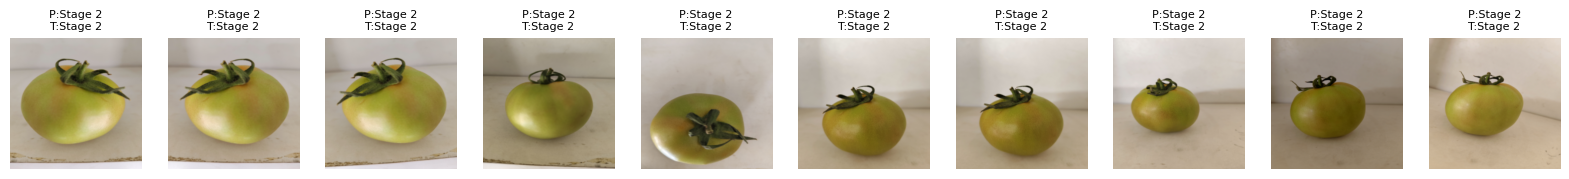


🔹 Stage 3 (showing 10 samples)


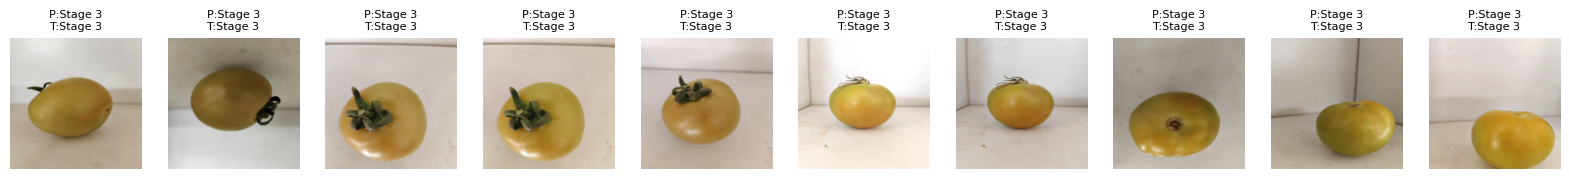


🔹 Stage 5 (showing 10 samples)


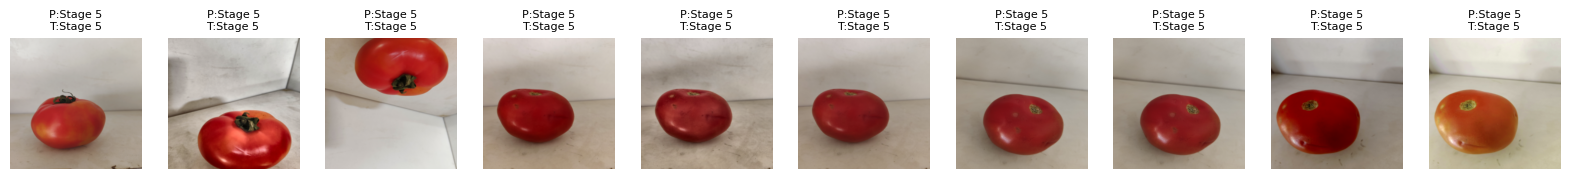


🔹 Stage1 (showing 10 samples)


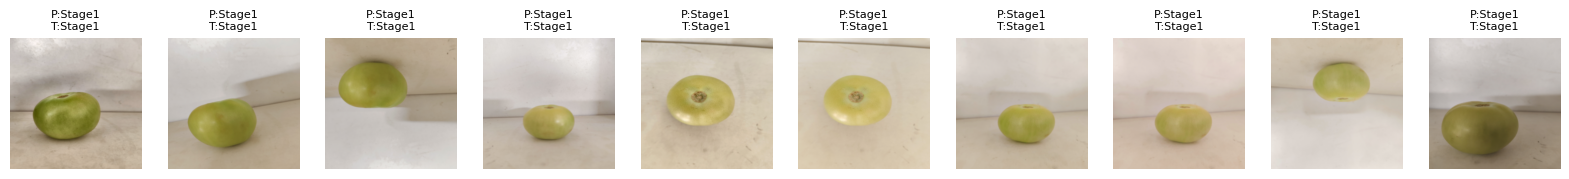


🔹 Stage4 (showing 10 samples)


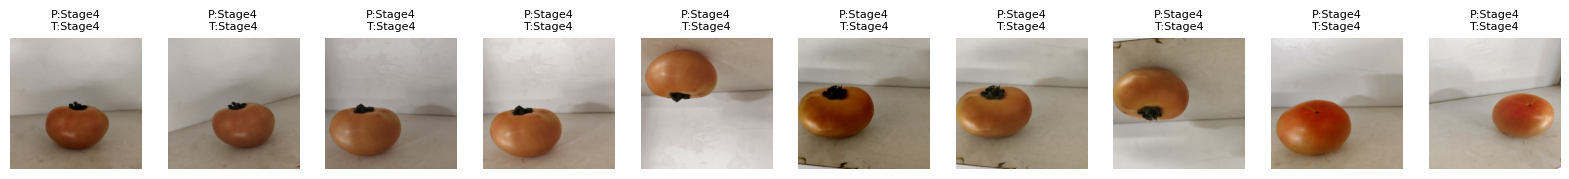

In [ ]:
def imshow_grid(images, preds, labels, class_names, n=10):
    # images: tensor [N, C, H, W]
    plt.figure(figsize=(n * 2, 5))  # adjust width and height
    for i in range(n):
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
        img = images[i].cpu() * std + mean

        npimg = img.cpu().numpy()
        plt.subplot(1, n, i + 1)
        plt.imshow(np.transpose(npimg, (1, 2, 0)))
        plt.title(f"P:{class_names[preds[i]]}\nT:{class_names[labels[i]]}", fontsize=8)
        plt.axis("off")
    plt.show()


model.eval()
class_names = train_data.classes

# Collect 10 images of each class
target_per_class = 10
collected_images = {cls: [] for cls in class_names}
collected_preds = {cls: [] for cls in class_names}
collected_labels = {cls: [] for cls in class_names}

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        for i in range(len(images)):
            true_label = class_names[labels[i]]
            if len(collected_images[true_label]) < target_per_class:
                collected_images[true_label].append(images[i].cpu())
                collected_preds[true_label].append(preds[i].cpu())
                collected_labels[true_label].append(labels[i].cpu())

        # Stop early if both classes filled
        if all(len(v) >= target_per_class for v in collected_images.values()):
            break

# Show 10 images for each class
for cls in class_names:
    imgs = torch.stack(collected_images[cls])
    preds = torch.stack(collected_preds[cls])
    labels = torch.stack(collected_labels[cls])

    print(f"\n🔹 {cls} (showing {target_per_class} samples)")
    imshow_grid(imgs, preds, labels, class_names, n=target_per_class)



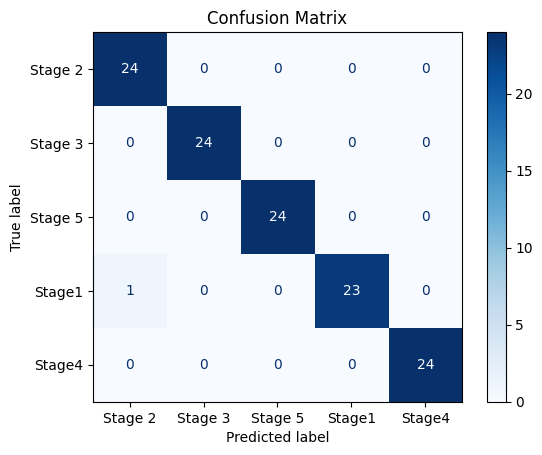

In [ ]:
#Confusion Matrix
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_data.classes)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()


In [ ]:
from google.colab import files
files.download("best_microvit_tomato.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import torch

model.eval()

dummy_input = torch.randn(1, 3, 224, 224).to(device)

onnx_path = "/content/drive/MyDrive/microvit_tomato.onnx"

torch.onnx.export(
    model,
    dummy_input,
    onnx_path,
    export_params=True,
    opset_version=18,   # match internal version
    do_constant_folding=True,
    input_names=["input"],
    output_names=["output"],
    dynamo=False        # VERY IMPORTANT
)

print("✅ ONNX model exported successfully!")

/tmp/ipython-input-2574077199.py:9: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


✅ ONNX model exported successfully!


In [ ]:
!ls /content/drive/MyDrive

 best_microvit_tomato.pth
'Colab Notebooks'
'Documents '
'Faltuu others'
 Final_Split_the_end
 Firayala
'Me with Faltu pic'
 microvit_tomato.onnx
 microvit_tomato.onnx.data
 Photos
'pradhan mantri jan dhan yojana documents required.gdoc'
 Tomato_dataset
 Tomato_Dataset
'#Yadpat Kitti'


In [ ]:
!cp best_microvit_tomato.pth /content/drive/MyDrive/

In [ ]:
!ls /content/drive/MyDrive

 best_microvit_tomato.pth
'Colab Notebooks'
'Documents '
'Faltuu others'
 Final_Split_the_end
 Firayala
'Me with Faltu pic'
 Photos
'pradhan mantri jan dhan yojana documents required.gdoc'
 Tomato_dataset
 Tomato_Dataset
'#Yadpat Kitti'


In [ ]:
!pip install onnx onnxscript


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.3/159.3 kB 21.5 MB/s eta 0:00:00
